Core libraries imported.
Project directories ready.
Environment loaded. Model tiers:
  WEAK   -> gpt-4o-mini
  MID    -> gpt-5.4-mini
  STRONG -> gpt-5.4
Conditions: ['C1', 'C2', 'C3', 'C4', 'C5']
Datasets   : ['D1', 'D2', 'D2_fin', 'D3']
Grayscale plotting style configured.
Condition styles: {'C1': '0.15', 'C2': '0.3', 'C3': '0.45', 'C4': '0.6', 'C5': '0.75'}
Live check skipped (set RUN_LIVE_CHECK=True to test credentials).
Setup complete. Config snapshot saved.
Loaded full results: n=32598.


,dataset,model_tier,condition,n,ctx_tokens,prompt_tokens,EX,cost
0,D1,MID,C1,1034,418.4816,681.3453,0.7573,0.0004
1,D1,MID,C2,1034,314.9410,550.8317,0.7495,0.0003
2,D1,MID,C4,1034,371.6925,613.9265,0.7611,0.0004
3,D1,STRONG,C1,1034,418.4816,681.3453,0.7785,0.0021
4,D1,STRONG,C2,1034,314.9410,550.8317,0.7785,0.0017
5,D1,STRONG,C4,1034,371.6925,613.9265,0.7776,0.0019
6,D1,WEAK,C1,1034,418.4816,682.3453,0.7466,0.0001
7,D1,WEAK,C2,1034,314.9410,551.8317,0.7311,0.0001
8,D1,WEAK,C4,1034,371.6925,614.9265,0.7437,0.0001
9,D2,MID,C1,500,3449.4220,5073.7940,0.5181,0.0027


Saved table: 04_rq2_token_table.csv, 04_rq2_token_table.tex


,dataset,model_tier,condition,ctx_tokens,savings_pct
0,D1,MID,C2,314.94,24.74
1,D1,MID,C4,371.69,11.18
2,D1,STRONG,C2,314.94,24.74
3,D1,STRONG,C4,371.69,11.18
4,D1,WEAK,C2,314.94,24.74
5,D1,WEAK,C4,371.69,11.18
6,D2,MID,C2,887.89,74.26
7,D2,MID,C4,2756.34,20.09
8,D2,STRONG,C2,887.89,74.26
9,D2,STRONG,C4,2756.34,20.09


Saved figure: 04_rq2_pareto.png, 04_rq2_pareto.pdf


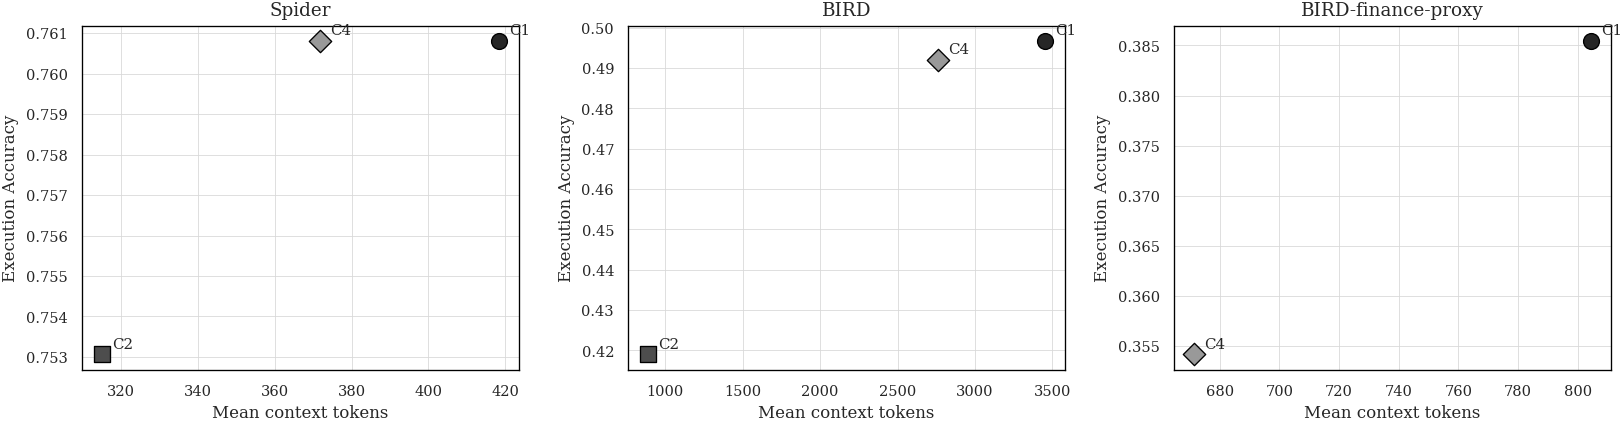

Saved figure: 04_rq2_savings_by_schema_size.png, 04_rq2_savings_by_schema_size.pdf


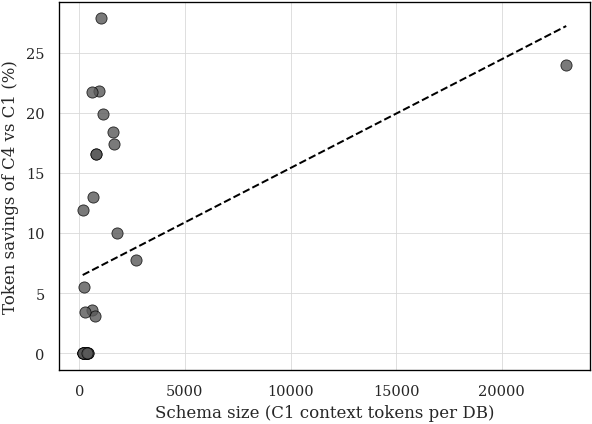

Saved figure: 04_rq2_cumulative_cost_D1_STRONG.png, 04_rq2_cumulative_cost_D1_STRONG.pdf


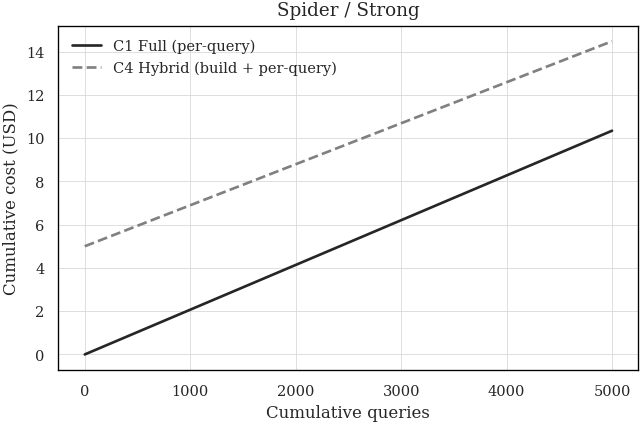

D1/STRONG: per-query cost C1=0.00207, C4=0.00189, break-even N*≈28,898 queries.
Saved figure: 04_rq2_cumulative_cost_D2_STRONG.png, 04_rq2_cumulative_cost_D2_STRONG.pdf


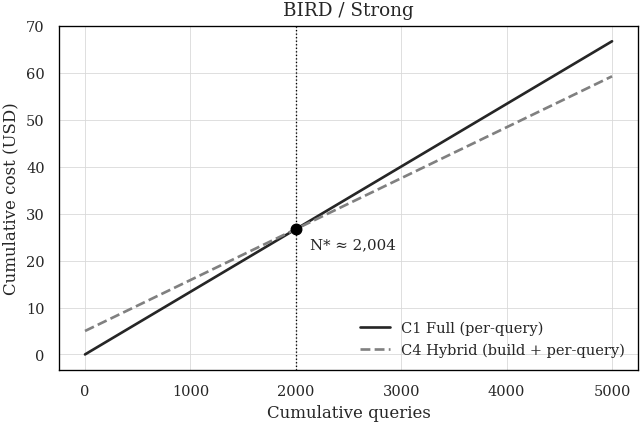

D2/STRONG: per-query cost C1=0.01336, C4=0.01086, break-even N*≈2,004 queries.
Saved figure: 04_rq2_cumulative_cost_D2_fin_STRONG.png, 04_rq2_cumulative_cost_D2_fin_STRONG.pdf


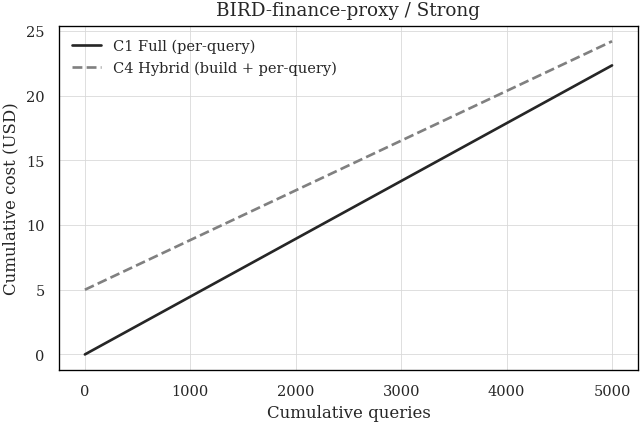

D2_fin/STRONG: per-query cost C1=0.00447, C4=0.00384, break-even N*≈7,977 queries.


In [1]:
# ============================================================================
# 04_rq2_token_cost.ipynb
# ----------------------------------------------------------------------------
# Beyond Full-Schema Prompting: A Graph-based Semantic Layer for Text-to-SQL
#
# RQ2: How much context token cost does the graph layer save as schemas grow, and
#      what is the accuracy-token trade-off? Plus Section 10 cost-benefit: the
#      break-even query count N* and a cumulative-cost curve (one-off graph build
#      vs per-query full-schema cost).
#
# Consumes : results/tables/generation_results.csv (or *_smoke.csv)
# Produces : 04_rq2_pareto.{png,pdf}                accuracy vs tokens
#            04_rq2_savings_by_schema_size.{png,pdf}
#            04_rq2_cumulative_cost.{png,pdf}        break-even (killer figure)
#            04_rq2_token_table.{csv,tex}
#
# Anonymity: no filesystem paths are printed.
# ============================================================================


# %% [markdown]
# ## Cell 1 - Load configuration + results

# %%
%run 00_setup_and_config.ipynb


# %%
def load_results():
    full = TABLES_DIR / "generation_results.csv"
    smoke = TABLES_DIR / "generation_results_smoke.csv"
    if full.exists():
        df = pd.read_csv(full); print(f"Loaded full results: n={len(df)}.")
    elif smoke.exists():
        df = pd.read_csv(smoke); print(f"[warning] using SMOKE data (n={len(df)}).")
    else:
        raise FileNotFoundError("Run notebook 02 first.")
    return df

res = load_results()


# %% [markdown]
# ## Cell 2 - Token summary by condition x dataset x model
# context_tokens_est = schema tokens injected into the prompt (the quantity the
# graph layer reduces). prompt_tokens = full billed input (schema + question).

# %%
RQ2_CONDITIONS = ["C1", "C2", "C4"]     # baseline vs vector vs hybrid
tok = res[res["condition"].isin(RQ2_CONDITIONS)].copy()

tok_table = (tok.groupby(["dataset", "model_tier", "condition"])
               .agg(n=("qid", "count"),
                    ctx_tokens=("context_tokens_est", "mean"),
                    prompt_tokens=("prompt_tokens", "mean"),
                    EX=("exec_match", "mean"),
                    cost=("cost_usd", "mean"))
               .reset_index())
tok_table = tok_table.round(4)
display(tok_table)
save_table(tok_table, "04_rq2_token_table")


# %% [markdown]
# ## Cell 3 - Token savings vs C1 baseline (%)

# %%
def savings_vs_c1(df):
    base = (df[df["condition"] == "C1"]
            .groupby(["dataset", "model_tier"])["context_tokens_est"].mean())
    rows = []
    for (ds, mt, cond), g in df.groupby(["dataset", "model_tier", "condition"]):
        if cond == "C1":
            continue
        b = base.get((ds, mt), np.nan)
        mean_ctx = g["context_tokens_est"].mean()
        rows.append({"dataset": ds, "model_tier": mt, "condition": cond,
                     "ctx_tokens": mean_ctx,
                     "savings_pct": 100.0 * (b - mean_ctx) / b if b else np.nan})
    return pd.DataFrame(rows)

rq2_savings = savings_vs_c1(tok).round(2)
display(rq2_savings)


# %% [markdown]
# ## Cell 4 - Figure: accuracy-token Pareto (grayscale)
# x = mean context tokens (lower is cheaper), y = EX (higher is better).
# Each point is a condition; the proposed C4 should sit up-and-left of C1.

# %%
def plot_pareto(df):
    d = df.dropna(subset=["exec_match"])
    if not len(d):
        print("No EX-scoreable rows yet for Pareto.")
        return
    datasets = sorted(d["dataset"].unique())
    fig, axes = plt.subplots(1, len(datasets),
                             figsize=(4.6 * len(datasets), 3.8), squeeze=False)
    for ax, ds in zip(axes[0], datasets):
        sub = d[d["dataset"] == ds]
        agg = (sub.groupby("condition")
                  .agg(x=("context_tokens_est", "mean"),
                       y=("exec_match", "mean")).reset_index())
        for _, r in agg.iterrows():
            st = CONDITION_STYLE.get(r["condition"], {})
            ax.scatter(r["x"], r["y"], s=90, color=st.get("color", "0.3"),
                       marker=st.get("marker", "o"), edgecolor="black",
                       linewidth=0.8, zorder=3)
            ax.annotate(r["condition"], (r["x"], r["y"]),
                        textcoords="offset points", xytext=(6, 4), fontsize=9)
        ax.set_xlabel("Mean context tokens")
        ax.set_ylabel("Execution Accuracy")
        ax.set_title(DATASETS.get(ds, ds))
    save_figure(fig, "04_rq2_pareto")
    plt.show()

plot_pareto(tok)


# %% [markdown]
# ## Cell 5 - Figure: token savings by schema size
# Tests the hypothesis that larger schemas yield larger savings. Schema size is
# proxied by the C1 context tokens per database (bigger C1 = bigger schema).

# %%
def plot_savings_by_size(df):
    # C1 tokens per (dataset, db) as the schema-size axis.
    c1 = df[df["condition"] == "C1"]
    if not len(c1):
        print("No C1 rows to measure schema size.")
        return
    size = (c1.groupby(["dataset", "db_id"])["context_tokens_est"]
              .mean().rename("schema_size"))
    c4 = df[df["condition"] == "C4"]
    c4m = (c4.groupby(["dataset", "db_id"])["context_tokens_est"]
             .mean().rename("c4_tokens"))
    m = pd.concat([size, c4m], axis=1).dropna()
    m["savings_pct"] = 100.0 * (m["schema_size"] - m["c4_tokens"]) / m["schema_size"]

    fig, ax = plt.subplots(figsize=(5.2, 3.8))
    ax.scatter(m["schema_size"], m["savings_pct"], s=45, color="0.35",
               edgecolor="black", linewidth=0.5, alpha=0.8)
    # trend line
    if len(m) >= 2:
        z = np.polyfit(m["schema_size"], m["savings_pct"], 1)
        xs = np.linspace(m["schema_size"].min(), m["schema_size"].max(), 50)
        ax.plot(xs, np.polyval(z, xs), color="black", linewidth=1.2, linestyle="--")
    ax.set_xlabel("Schema size (C1 context tokens per DB)")
    ax.set_ylabel("Token savings of C4 vs C1 (%)")
    save_figure(fig, "04_rq2_savings_by_schema_size")
    plt.show()

plot_savings_by_size(tok)


# %% [markdown]
# ## Cell 6 - Break-even N* and cumulative-cost curve (Section 10.1)
# One-off graph build cost vs per-query full-schema premium. N* is where the two
# cumulative-cost lines cross. GRAPH_BUILD_COST_USD is a parameter you set from
# your own build accounting; the default is illustrative.

# %%
# EDIT this to your measured one-time build cost (embeddings + any LLM/labor $).
GRAPH_BUILD_COST_USD = 5.0     # illustrative placeholder

def cumulative_cost_curve(df, dataset, model_tier,
                          build_cost=GRAPH_BUILD_COST_USD, max_q=5000):
    sub = df[(df["dataset"] == dataset) & (df["model_tier"] == model_tier)]
    c1 = sub[sub["condition"] == "C1"]["cost_usd"].mean()
    c4 = sub[sub["condition"] == "C4"]["cost_usd"].mean()
    if np.isnan(c1) or np.isnan(c4):
        return None
    q = np.arange(0, max_q + 1)
    full_cum = c1 * q                      # full-schema: pure per-query
    hybrid_cum = build_cost + c4 * q       # hybrid: one-off build + cheaper/query
    per_query_saving = c1 - c4
    n_star = (build_cost / per_query_saving) if per_query_saving > 0 else np.inf
    return q, full_cum, hybrid_cum, n_star, c1, c4

def plot_break_even(df, dataset, model_tier="STRONG"):
    out = cumulative_cost_curve(df, dataset, model_tier)
    if out is None:
        print(f"Cost data unavailable for {dataset}/{model_tier}.")
        return
    q, full_cum, hybrid_cum, n_star, c1, c4 = out
    fig, ax = plt.subplots(figsize=(5.6, 3.8))
    ax.plot(q, full_cum, color="0.15", linestyle="-", linewidth=1.6,
            label="C1 Full (per-query)")
    ax.plot(q, hybrid_cum, color="0.5", linestyle="--", linewidth=1.6,
            label="C4 Hybrid (build + per-query)")
    if np.isfinite(n_star) and n_star <= q.max():
        y = c1 * n_star
        ax.axvline(n_star, color="black", linewidth=0.8, linestyle=":")
        ax.scatter([n_star], [y], color="black", zorder=4, s=40)
        ax.annotate(f"N* ≈ {n_star:,.0f}", (n_star, y),
                    textcoords="offset points", xytext=(8, -12), fontsize=9)
    ax.set_xlabel("Cumulative queries")
    ax.set_ylabel("Cumulative cost (USD)")
    ax.set_title(f"{DATASETS.get(dataset, dataset)} / "
                 f"{MODEL_TIER_LABELS.get(model_tier, model_tier)}")
    ax.legend()
    save_figure(fig, f"04_rq2_cumulative_cost_{dataset}_{model_tier}")
    plt.show()
    print(f"{dataset}/{model_tier}: per-query cost C1={c1:.5f}, C4={c4:.5f}, "
          f"break-even N*≈{n_star:,.0f} queries.")

for ds in sorted(res["dataset"].unique()):
    plot_break_even(res, ds, "STRONG")